In [1]:
import sys
sys.path.append("..")
import pandas as pd 
import matplotlib.pyplot as plt
from sql_queries.analytics import monthly_revenue

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = monthly_revenue()
print(df.shape)
df.head()

(48, 2)


,month,total_revenue
0,2014-01,14236.90
1,2014-02,4519.89
2,2014-03,55691.01
3,2014-04,28295.35
4,2014-05,23648.29


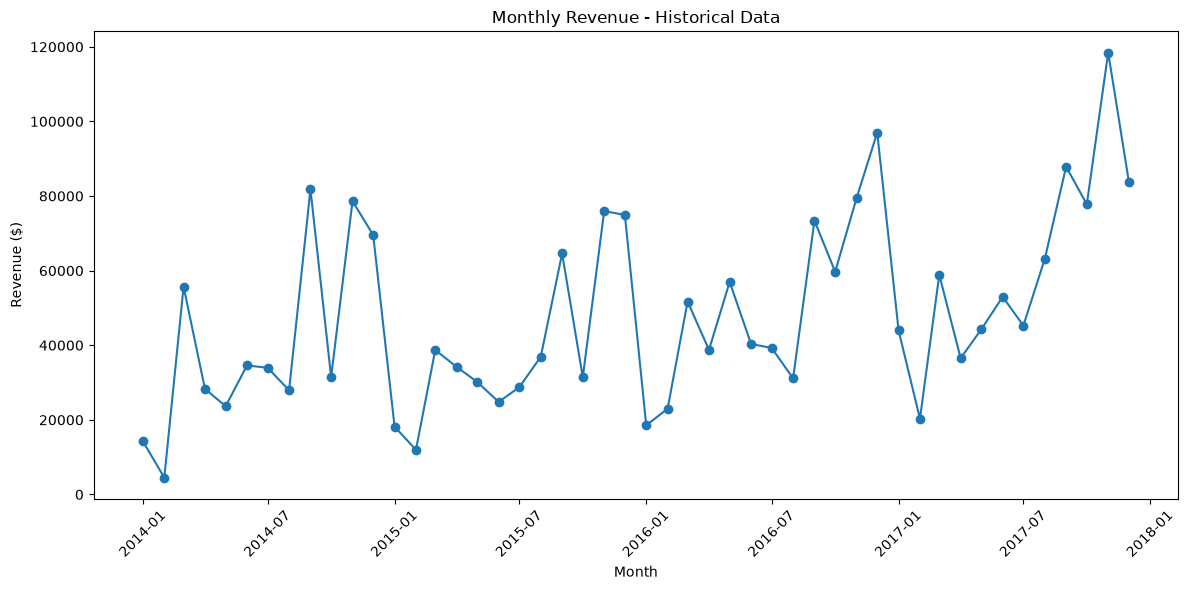

In [3]:
df['month'] = pd.to_datetime(df['month'])

df = df.sort_values(by='month').reset_index (drop=True)

#Visualize the data
plt.figure(figsize=(12,6))
plt.plot(df['month'], df['total_revenue'], marker='o')
plt.title('Monthly Revenue - Historical Data')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

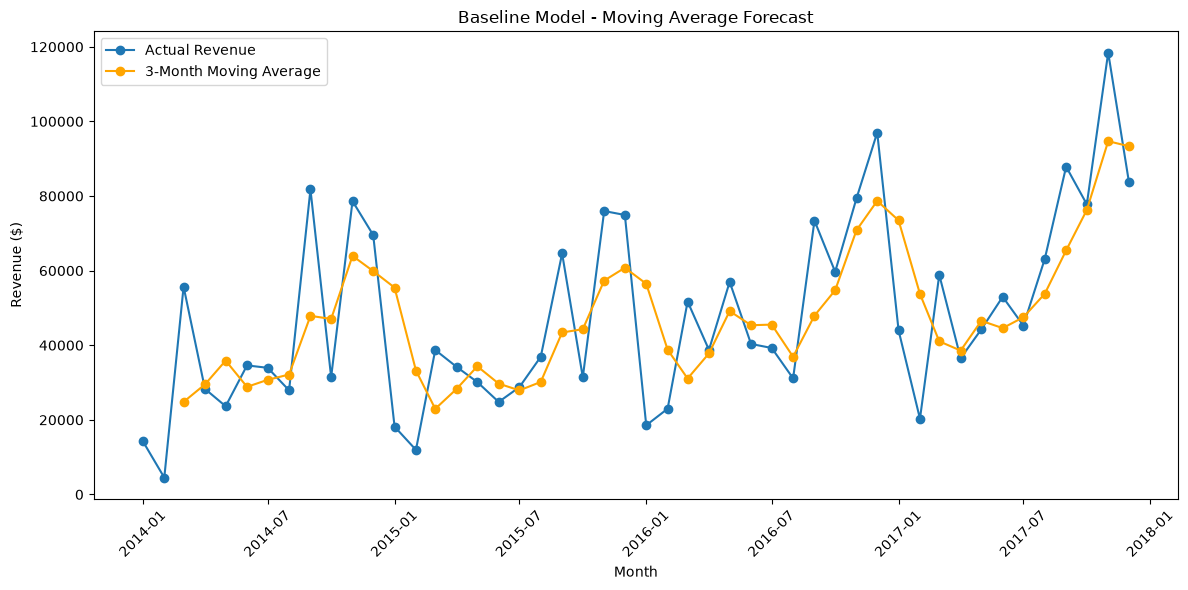

In [4]:
df['moving_avg'] = df['total_revenue'].rolling(window=3).mean()

plt.figure(figsize=(12,6))
plt.plot(df['month'], df['total_revenue'], marker='o', label='Actual Revenue')
plt.plot(df['month'], df['moving_avg'], marker='o', label='3-Month Moving Average', color='orange')
plt.title('Baseline Model - Moving Average Forecast')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
from prophet import Prophet

prophet_df = df[['month', 'total_revenue']].rename(columns={'month': 'ds', 'total_revenue': 'y'})

model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=6, freq='ME')
forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

22:27:35 - cmdstanpy - INFO - Chain [1] start processing
22:27:35 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
44,2017-09-01,88000.200374,79593.716432,96815.862191
45,2017-10-01,66019.908200,57538.794589,74710.585392
46,2017-11-01,100051.688339,91219.155199,109062.406866
47,2017-12-01,94971.165014,86420.761711,103550.519976
48,2017-12-31,32512.809956,24165.820016,40965.273312
49,2018-01-31,53334.109925,45623.716898,62083.565732
50,2018-02-28,72433.997364,63759.894354,81082.953415
51,2018-03-31,63522.704049,55290.780562,72747.861644
52,2018-04-30,33971.785551,25207.211976,42206.117738
53,2018-05-31,52957.191660,44137.846579,61894.264040


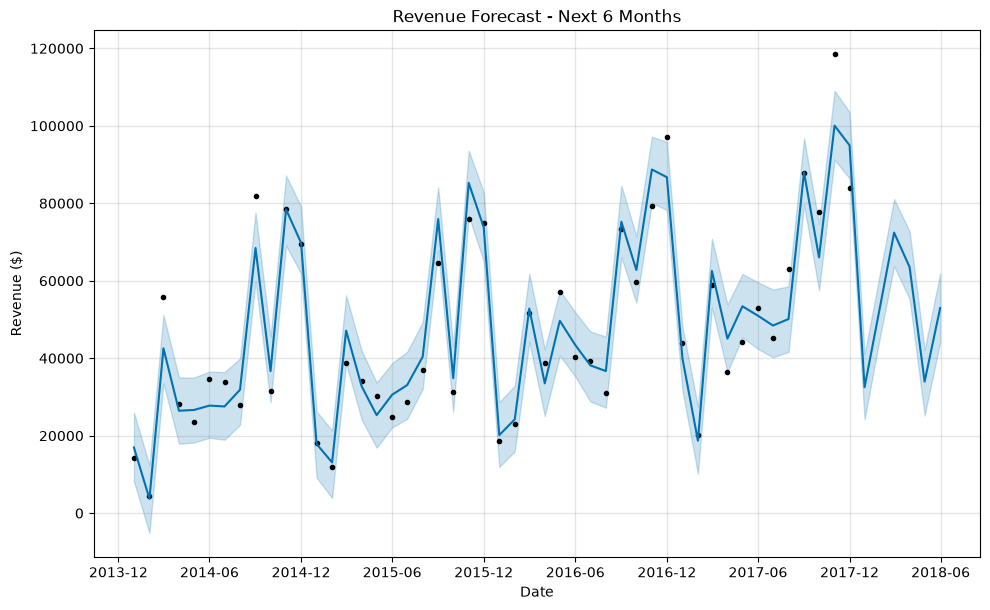

In [9]:
fig = model.plot(forecast)
plt.title('Revenue Forecast - Next 6 Months')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.show()

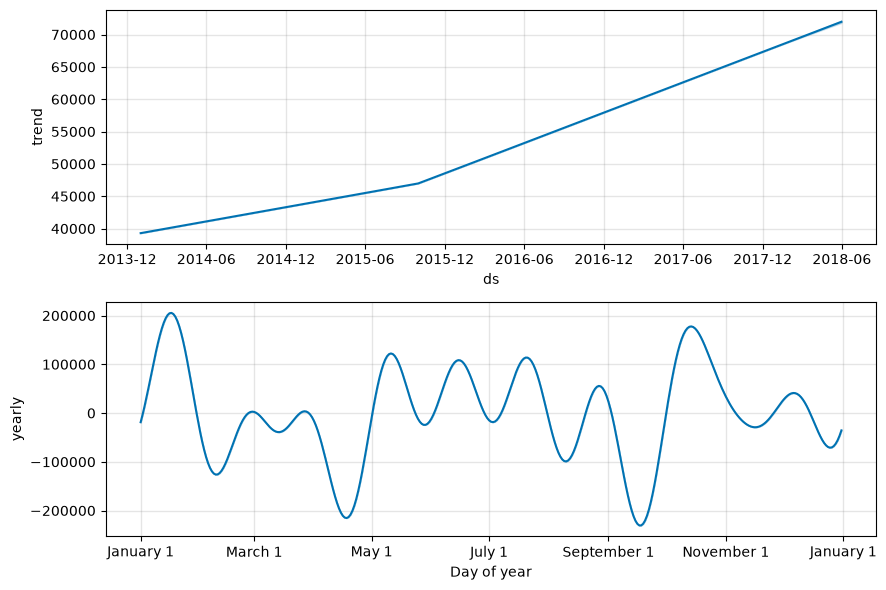

In [10]:
fig2 = model.plot_components(forecast)
plt.show()

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

actual = prophet_df['y'].values
forecast_values = forecast['yhat'][:len(actual)].values

mae = mean_absolute_error(actual, forecast_values)
mse = mean_squared_error(actual, forecast_values)
rmse = np.sqrt(mse)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Mean Absolute Error (MAE): 5203.24
Root Mean Squared Error (RMSE): 6762.71
